In [1]:
import sys
sys.path.append('..')

In [2]:
from glob import glob

import numpy as np
from sklearn.metrics import classification_report
from keras.optimizers import SGD
from keras.models import Sequential
from keras.metrics import BinaryAccuracy
from keras.losses import BinaryCrossentropy
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

from utils.image_classification.data import (
    show_random_images, train_test_split_by_list,
    create_train_val_df, create_img_data_generator
)
from utils.image_classification.docs import print_cnn_docs
from utils.log import log_loss

# 1. Prepare data

In [3]:
OK_IMG_FOLDER_PATH = 'data/LG_Innotek_Data/ok_img/*.jpg'
NG_IMG_FOLDER_PATH = 'data/LG_Innotek_Data/ng_img/*.jpg'

In [4]:
ok_img_list = glob(OK_IMG_FOLDER_PATH)
len(ok_img_list)

1138

In [5]:
ng_img_list = glob(NG_IMG_FOLDER_PATH)
len(ng_img_list)

956

## Visualize data

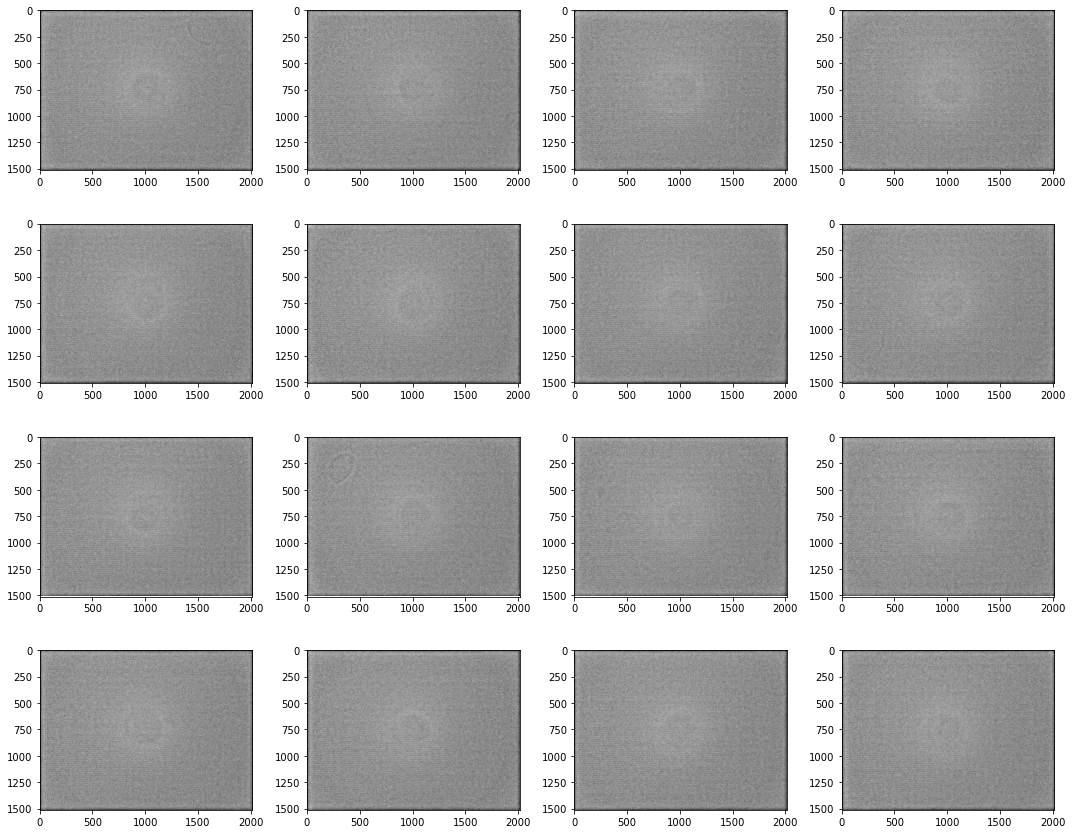

In [6]:
show_random_images(ok_img_list)

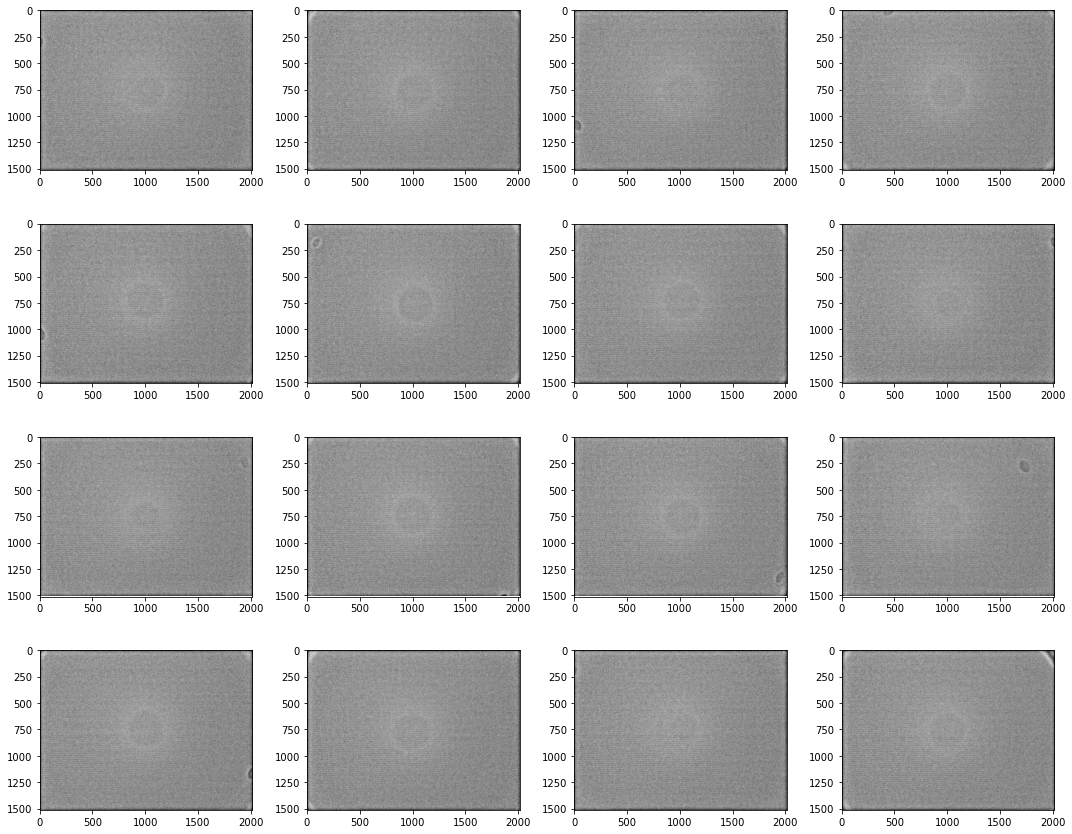

In [7]:
show_random_images(ng_img_list)

## Split data into train and val set

In [8]:
val_percent = 0.2

In [9]:
data_dict = {
    'ok': ok_img_list,
    'ng': ng_img_list
}

In [10]:
splitted_data_dict = train_test_split_by_list(data_dict, val_percent)
splitted_data_dict.keys()

dict_keys(['ok', 'ng'])

In [11]:
splitted_data_dict['ok'].keys()

dict_keys(['train_img_paths', 'val_img_paths', 'train_labels', 'val_labels', 'train_labels_idx', 'val_labels_idx'])

In [12]:
splitted_data_dict['ng'].keys()

dict_keys(['train_img_paths', 'val_img_paths', 'train_labels', 'val_labels', 'train_labels_idx', 'val_labels_idx'])

In [13]:
train_df, val_df = create_train_val_df(splitted_data_dict)

In [14]:
train_df

,image_path,label,labels_idx
0,data/LG_Innotek_Data/ok_img/GCF3177C3KE1CXC2Z_...,ok,0
1,data/LG_Innotek_Data/ok_img/GCF317109P91CXC2U_...,ok,0
2,data/LG_Innotek_Data/ok_img/GCF3177C3E21CXC2S_...,ok,0
3,data/LG_Innotek_Data/ok_img/GCF317109JS1CXC2S_...,ok,0
4,data/LG_Innotek_Data/ok_img/GCF317109YE1CXC2W_...,ok,0
...,...,...,...
1669,data/LG_Innotek_Data/ng_img/GCF317345JP1CXC3G_...,ng,1
1670,data/LG_Innotek_Data/ng_img/GCF317147QF1CXC1C_...,ng,1
1671,data/LG_Innotek_Data/ng_img/GCF314778L21CXC4M_...,ng,1
1672,data/LG_Innotek_Data/ng_img/GCF31729WP71CXC3C_...,ng,1


In [15]:
val_df

,image_path,label,labels_idx
0,data/LG_Innotek_Data/ok_img/GCF317109RP1CXC28_...,ok,0
1,data/LG_Innotek_Data/ok_img/GCF3177C3431CXC2M_...,ok,0
2,data/LG_Innotek_Data/ok_img/GCF3177C3LE1CXC2W_...,ok,0
3,data/LG_Innotek_Data/ok_img/GCF31369ZE11CXC2K_...,ok,0
4,data/LG_Innotek_Data/ok_img/GCF3177C34V1CXC2V_...,ok,0
...,...,...,...
415,data/LG_Innotek_Data/ng_img/GCF3166C4DN1CXC1F_...,ng,1
416,data/LG_Innotek_Data/ng_img/GCF318416TN1CXC2X_...,ng,1
417,data/LG_Innotek_Data/ng_img/GCF3162C4K11CXC1N_...,ng,1
418,data/LG_Innotek_Data/ng_img/GCF3177A5TH1CXC1D_...,ng,1


## Keras Image Data Generator

In [16]:
IMG_SIZE = 64
BATCH_SIZE = 8

In [17]:
train_data_gen = create_img_data_generator(train_df, IMG_SIZE, BATCH_SIZE)

Found 1674 validated image filenames belonging to 2 classes.


In [18]:
val_data_gen = create_img_data_generator(val_df, IMG_SIZE, BATCH_SIZE * 2)

Found 420 validated image filenames belonging to 2 classes.


# 2. Build and train model

## Build model

In [19]:
print_cnn_docs()


        1. Conv2D(filters, kernel_size, strides, padding, ...) 

        https://keras.io/api/layers/convolution_layers/convolution2d/ 

        2. BatchNormalization() 

        https://keras.io/api/layers/normalization_layers/batch_normalization/ 

        3. MaxPooling2D(pool_size, strides, padding, ...) 

        https://keras.io/api/layers/pooling_layers/max_pooling2d/ 

        4. Flatten() 

        https://keras.io/api/layers/reshaping_layers/flatten/ 

        5. Dense(units, activation, ...) 

        https://keras.io/api/layers/core_layers/dense/ 

        6. Dropout(rate) 

        https://keras.io/api/layers/regularization_layers/dropout/ 

    


In [20]:
model = Sequential([
    Conv2D(8, 3, 1, 'same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(8, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(16, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(32, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, 3, 1, 'same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, 'relu'),
    Dropout(rate=0.3),
    Dense(1, 'sigmoid')
])

model.summary()

2023-07-22 22:13:28.758711: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 8)         224       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 8)         584       
_________________________________________________________________
batch_normalization (BatchNo (None, 64, 64, 8)         32        
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 32, 32, 8)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 16)        1168      
_________________________________________________________________
batch_normalization_1 (Batch (None, 32, 32, 16)        64        
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 16)        0

## Compile model

In [21]:
bce_loss = BinaryCrossentropy()

In [22]:
opt = SGD(learning_rate=0.001)

In [23]:
model.compile(loss=bce_loss, optimizer=opt, metrics=[BinaryAccuracy()])

In [24]:
NUM_EPOCH = 20

## Train model

In [25]:
history = model.fit(
    x=train_data_gen,
    epochs=NUM_EPOCH,
    validation_data=val_data_gen,
    shuffle=True
)

2023-07-22 22:13:29.593150: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


Epoch 1/20
210/210 [==============================] - 97s 453ms/step - loss: 0.9852 - binary_accuracy: 0.5215 - val_loss: 0.7116 - val_binary_accuracy: 0.4714
Epoch 2/20
210/210 [==============================] - 103s 490ms/step - loss: 0.8076 - binary_accuracy: 0.5479 - val_loss: 0.7287 - val_binary_accuracy: 0.5286
Epoch 3/20
210/210 [==============================] - 79s 376ms/step - loss: 0.7872 - binary_accuracy: 0.4978 - val_loss: 0.7178 - val_binary_accuracy: 0.5405
Epoch 4/20
210/210 [==============================] - 69s 327ms/step - loss: 0.7296 - binary_accuracy: 0.5510 - val_loss: 0.7404 - val_binary_accuracy: 0.4500
Epoch 5/20
210/210 [==============================] - 68s 326ms/step - loss: 0.6791 - binary_accuracy: 0.5818 - val_loss: 0.7247 - val_binary_accuracy: 0.5238
Epoch 6/20
210/210 [==============================] - 72s 342ms/step - loss: 0.6439 - binary_accuracy: 0.6463 - val_loss: 0.7416 - val_binary_accuracy: 0.4881
Epoch 7/20
210/210 [=========================

# 3. Evaluate model

In [26]:
history.history.keys()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])

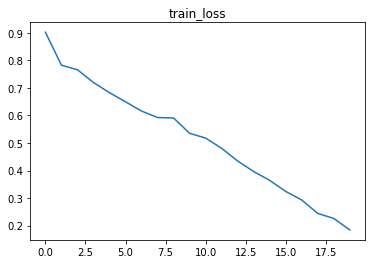

In [27]:
log_loss(range(NUM_EPOCH), history.history['loss'], 'train_loss')

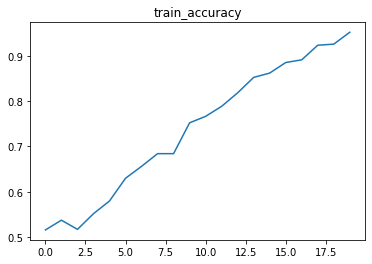

In [28]:
log_loss(range(NUM_EPOCH), history.history['binary_accuracy'], 'train_accuracy')

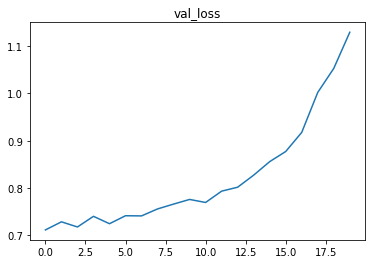

In [29]:
log_loss(range(NUM_EPOCH), history.history['val_loss'], 'val_loss')

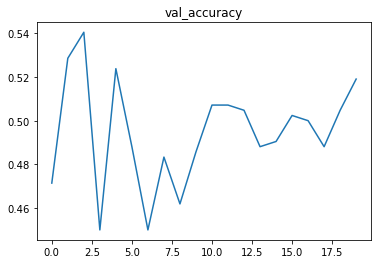

In [30]:
log_loss(range(NUM_EPOCH), history.history['val_binary_accuracy'], 'val_accuracy')

# 4. Predict new data

In [31]:
pred_prob = model.predict(val_data_gen)
pred_prob

array([[0.8596924 ],
       [0.16329029],
       [0.84632456],
       [0.92891884],
       [0.9891609 ],
       [0.5911709 ],
       [0.9179932 ],
       [0.10509381],
       [0.5284032 ],
       [0.690717  ],
       [0.32086694],
       [0.52551347],
       [0.04934976],
       [0.68228865],
       [0.8292664 ],
       [0.9942856 ],
       [0.7527584 ],
       [0.9834851 ],
       [0.9573257 ],
       [0.62221956],
       [0.6151092 ],
       [0.45709383],
       [0.32856226],
       [0.25321633],
       [0.15484074],
       [0.9502915 ],
       [0.66910887],
       [0.22525743],
       [0.8276242 ],
       [0.7081214 ],
       [0.9292041 ],
       [0.16637924],
       [0.29464227],
       [0.87815964],
       [0.1093992 ],
       [0.98584104],
       [0.7541044 ],
       [0.4489175 ],
       [0.98654616],
       [0.2721768 ],
       [0.29666764],
       [0.9978428 ],
       [0.9634625 ],
       [0.5421138 ],
       [0.67057055],
       [0.8865688 ],
       [0.96827203],
       [0.081

In [32]:
CONFIDENCE_THRESHOLD = 0.5

In [33]:
y_pred = np.where(pred_prob > CONFIDENCE_THRESHOLD, 1, 0).squeeze()
y_pred

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,

In [34]:
y_pred.shape

(420,)

In [35]:
y_true = val_df['labels_idx']
y_true.shape

(420,)

In [36]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.28      0.36       228
           1       0.44      0.68      0.54       192

    accuracy                           0.46       420
   macro avg       0.48      0.48      0.45       420
weighted avg       0.48      0.46      0.44       420

